In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [3]:
orders = pd.read_csv(r"C:\Users\Raj\Desktop\BESANT 2025\data_analysis\brazilian_eda\data\olist_orders_dataset.csv")
orders_item = pd.read_csv(r"C:\Users\Raj\Desktop\BESANT 2025\data_analysis\brazilian_eda\data\olist_order_items_dataset.csv")
customers = pd.read_csv(r"C:\Users\Raj\Desktop\BESANT 2025\data_analysis\brazilian_eda\data\olist_customers_dataset.csv")
product = pd.read_csv(r"C:\Users\Raj\Desktop\BESANT 2025\data_analysis\brazilian_eda\data\olist_products_dataset.csv")
payment = pd.read_csv(r"C:\Users\Raj\Desktop\BESANT 2025\data_analysis\brazilian_eda\data\olist_order_payments_dataset.csv")

In [4]:
data = orders.merge(orders_item,on = 'order_id')

In [5]:
data = data.merge(customers,on = 'customer_id')

In [6]:
data = data.merge(product,on = 'product_id')

In [7]:
payment_agg = payment.groupby('order_id')['payment_value'].sum().reset_index()
payment_agg

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,fffce4705a9662cd70adb13d4a31832d,116.85
99438,fffe18544ffabc95dfada21779c9644f,64.71


In [8]:
data = data.merge(payment_agg, on='order_id', how='left')

In [9]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_value'],
      dtype='str')

In [10]:
data.groupby("order_id").size().sort_values(ascending = True)

order_id
00010242fe8c5a6d1ba2dd792cb16214     1
000c3e6612759851cc3cbb4b83257986     1
000e562887b1f2006d75e0be9558292e     1
000e63d38ae8c00bbcb5a30573b99628     1
000e906b789b55f64edcb1f84030f90d     1
                                    ..
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
8272b63d03f5f79c56e9e4120aec44ef    21
Length: 98666, dtype: int64

In [11]:
data.groupby("order_id").size().sort_values(ascending = True)

order_id
00010242fe8c5a6d1ba2dd792cb16214     1
000c3e6612759851cc3cbb4b83257986     1
000e562887b1f2006d75e0be9558292e     1
000e63d38ae8c00bbcb5a30573b99628     1
000e906b789b55f64edcb1f84030f90d     1
                                    ..
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
8272b63d03f5f79c56e9e4120aec44ef    21
Length: 98666, dtype: int64

In [12]:
orders_item.groupby('order_id').size().sort_values(ascending = True).head(10)

order_id
00010242fe8c5a6d1ba2dd792cb16214    1
000c3e6612759851cc3cbb4b83257986    1
000e562887b1f2006d75e0be9558292e    1
000e63d38ae8c00bbcb5a30573b99628    1
000e906b789b55f64edcb1f84030f90d    1
000f25f4d72195062c040b12dce9a18a    1
001021efaa8636c29475e7734483457d    1
0010b2e5201cc5f1ae7e9c6cc8f5bd00    1
00119ff934e539cf26f92b9ef0cdfed8    1
0011d82c4b53e22e84023405fb467e57    1
dtype: int64

In [13]:
data.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
order_item_id                      int64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
product_category_name                str
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_c

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   customer_id                    112650 non-null  str    
 2   order_status                   112650 non-null  str    
 3   order_purchase_timestamp       112650 non-null  str    
 4   order_approved_at              112635 non-null  str    
 5   order_delivered_carrier_date   111456 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  112650 non-null  str    
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  str    
 10  seller_id                      112650 non-null  str    
 11  shipping_limit_date            112650 non-null  str    
 12  price                          112650 non

In [15]:
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['order_approved_at'] = pd.to_datetime(data['order_approved_at'])
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date'])

In [16]:
data['price'] = pd.to_numeric(data['price'],errors = 'coerce')
data['freight_value'] = pd.to_numeric(data['freight_value'],errors = 'coerce')

In [17]:
data['product_category_name'] = data['product_category_name'].astype('category')

In [18]:
data.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
payment_valu

In [19]:
data['order_status'].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

delivery status

In [20]:
data_delivered = data[data['order_status']=='Delivered']

Delivery Time

In [21]:
data.tail(30)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
112620,3cea94817a51f34aa5937784fb4a3219,20b927d23e84dfaa333eb4aea6615084,delivered,2018-04-01 16:13:26,2018-04-01 16:30:16,2018-04-02 18:21:51,2018-04-06 21:32:35,2018-04-19 00:00:00,1,e3dd336775af78a83fc27ed85f0f15da,...,MG,beleza_saude,47.0,1267.0,1.0,300.0,20.0,9.0,15.0,460.61
112621,e8fd20068b9f7e6ec07068bb7537f781,609b9fb8cad4fe0c7b376f77c8ab76ad,delivered,2017-08-10 21:21:07,2017-08-10 21:35:26,2017-08-18 16:42:51,2017-08-23 15:36:29,2017-08-31 00:00:00,1,0df37da38a30a713453b03053d60d3f7,...,SP,esporte_lazer,53.0,1105.0,1.0,2800.0,28.0,23.0,23.0,748.24
112622,e8fd20068b9f7e6ec07068bb7537f781,609b9fb8cad4fe0c7b376f77c8ab76ad,delivered,2017-08-10 21:21:07,2017-08-10 21:35:26,2017-08-18 16:42:51,2017-08-23 15:36:29,2017-08-31 00:00:00,2,0df37da38a30a713453b03053d60d3f7,...,SP,esporte_lazer,53.0,1105.0,1.0,2800.0,28.0,23.0,23.0,748.24
112623,c627fe35fce1a754bc5b812d0b8ff379,42b0671b440d1f2527bddd8b723e0a0c,delivered,2018-06-03 18:44:31,2018-06-03 18:55:15,2018-06-04 13:48:00,2018-06-07 13:22:19,2018-07-11 00:00:00,1,2d4114b81581f8c123e9d78743d9221a,...,SP,brinquedos,44.0,1421.0,2.0,806.0,34.0,21.0,32.0,206.20
112624,e6cc57f923c4dab2222b8c9aa8742eea,2f4a42f9bb4b9a8cd402fa549df5c7fd,delivered,2018-02-07 12:09:45,2018-02-07 12:31:13,2018-02-21 23:38:05,2018-03-05 18:56:39,2018-05-11 00:00:00,1,7b35ccd93a2184646c03b70326626923,...,DF,esporte_lazer,30.0,2162.0,1.0,1563.0,20.0,16.0,17.0,128.54
112625,788541a19c0791de0504c5a9cb7e7bd5,a537aaf902d2f436eb7f44817154bb68,delivered,2017-11-30 17:54:28,2017-11-30 18:16:25,2017-12-05 20:58:57,2017-12-13 20:34:50,2017-12-27 00:00:00,1,27d0fc55e3d2fe698088f2603e0a2ab6,...,PR,moveis_decoracao,29.0,257.0,1.0,5350.0,40.0,20.0,40.0,147.35
112626,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-03 20:26:19,2017-10-06 16:58:25,2017-10-24 00:00:00,1,9e10ae46a3021a02f1692448ef9fa1db,...,SP,beleza_saude,45.0,2231.0,3.0,175.0,21.0,3.0,15.0,49.75
112627,f9e3402be5a5ea63344347582ca9f45f,6f2cf56878f7f82151b0ad02590192c0,delivered,2017-06-07 11:02:37,2017-06-08 02:45:24,2017-06-08 14:03:29,2017-06-19 19:19:30,2017-07-05 00:00:00,1,5f21301936c11698db6aee5444190da0,...,ES,perfumaria,57.0,397.0,1.0,367.0,23.0,12.0,16.0,164.70
112628,6f46d42016226f77893ed3978d6903d0,3803547f820b1e10b7ad9c7985f06753,delivered,2017-07-05 15:55:19,2017-07-05 17:43:48,2017-07-07 19:48:40,2017-07-19 22:10:03,2017-08-14 00:00:00,1,9cbe4a1fd4db99c14512e9b2ff033ec4,...,RS,cama_mesa_banho,46.0,113.0,1.0,500.0,40.0,4.0,30.0,43.00
112629,dfc6eb45a2753ed9e6c6ef4987b44503,a046c690e0564ffde0ce611b5eee2c30,delivered,2018-05-25 17:05:17,2018-05-25 17:15:21,2018-05-29 13:31:00,2018-06-04 23:54:32,2018-06-26 00:00:00,1,829002c1d5f40820ebbc6ecd4bcdf3ab,...,MG,casa_construcao,59.0,664.0,1.0,5150.0,30.0,35.0,30.0,173.63


Time Based Sales Analaysis

In [22]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_value'],
      dtype='str')

In [23]:
data.to_csv("Cleaned.csv",index = False)

In [24]:
#  Extraction of time feature (Year,Month,Day)

# data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])

data['Year'] = data['order_purchase_timestamp'].dt.year
data['Month'] = data['order_purchase_timestamp'].dt.month
data['Month_name'] = data['order_purchase_timestamp'].dt.month_name()
data['Day'] = data['order_purchase_timestamp'].dt.day

In [25]:
data.head(30)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value,Year,Month,Month_name,Day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,38.71,2017,10,October,2
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,141.46,2018,7,July,24
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,179.12,2018,8,August,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,72.20,2017,11,November,18
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,28.62,2018,2,February,13
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1,060cb19345d90064d1015407193c233d,...,1.0,7150.0,65.0,10.0,65.0,175.26,2017,7,July,9
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09 00:00:00,1,a1804276d9941ac0733cfd409f5206eb,...,NaN,600.0,35.0,35.0,15.0,65.95,2017,4,April,11
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1,4520766ec412348b8d4caa5e8a18c464,...,1.0,50.0,16.0,16.0,17.0,75.16,2017,5,May,16
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1,ac1789e492dcd698c5c10b97a671243a,...,2.0,300.0,35.0,35.0,15.0,35.95,2017,1,January,23
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1,9a78fb9862b10749a117f7fc3c31f051,...,1.0,9750.0,42.0,41.0,42.0,169.76,2017,7,July,29


Monthly sales trend

In [26]:
monthly_sales = data.groupby('Month_name')['payment_value'].sum().sort_values()
monthly_sales

Month_name
September    1016363.55
December     1042875.48
October      1095083.85
November     1583869.01
January      1596145.06
February     1650183.59
June         1898348.08
April        2002477.05
March        2002561.61
July         2088998.42
August       2099749.62
May          2231479.39
Name: payment_value, dtype: float64

Monthly sales trend

In [27]:
monthly_sales = data.groupby(['Year','Month'])['payment_value'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(['Year','Month'])
monthly_sales

,Year,Month,payment_value
0,2016,9,347.52
1,2016,10,73914.58
2,2016,12,19.62
3,2017,1,187779.41
4,2017,2,344134.79
5,2017,3,526961.66
6,2017,4,505665.53
7,2017,5,724504.55
8,2017,6,600753.27
9,2017,7,737293.08


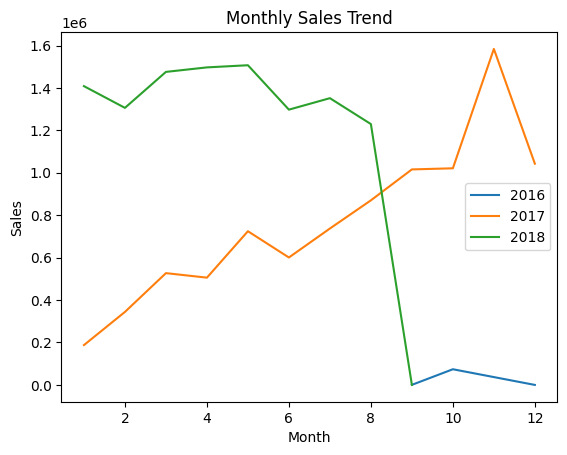

In [28]:
import matplotlib.pyplot as plt
for year in monthly_sales['Year'].unique():
    data = monthly_sales[monthly_sales['Year']== year]
    plt.plot(data['Month'],data['payment_value'],label = year)
plt.legend()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

The chart illustrates a comparative analysis of monthly sales trends across the years 2016, 2017, and 2018, providing a clear view of how sales performance has evolved over time. The x-axis represents the months from January to December, while the y-axis reflects the sales values at a large scale, indicating significant transaction volumes. Each line corresponds to a different year, enabling a straightforward year-over-year comparison. The data shows that 2016 experienced very low sales throughout the year, with minimal activity and only a slight increase around October, suggesting either limited business operations or incomplete data for that period. In contrast, 2017 demonstrates a strong and consistent upward trend, beginning with moderate sales in January and gradually increasing throughout the year, with minor fluctuations. The most notable peak occurs in November, making it the highest-performing month across all years, likely driven by seasonal demand such as festive or promotional periods. Although there is a slight dip in December, sales remain relatively high, indicating sustained momentum.

The performance in 2018 starts exceptionally strong, with sales levels already surpassing those of 2017 in the early months, and reaching peak values around April or May. However, after mid-year, the trend begins to decline gradually, followed by a sharp and unrealistic drop to zero after August. This sudden drop strongly suggests missing or incomplete data rather than an actual business decline, which limits the ability to fully assess the year’s performance. Overall, the chart highlights significant growth from 2016 to 2017, indicating improved business operations and increased market demand. It also suggests that 2018 had the potential to outperform previous years if complete data were available. Additionally, the visualization emphasizes the importance of seasonal patterns, particularly the strong sales observed toward the end of the year, and underscores the critical need for accurate and complete data to ensure reliable insights and decision-making.
